# Agriculture Health - Data Engineering Notebook

**Course:** ISB46703 Principle of Artificial Intelligence  
**Role:** Data Engineer  
**Domain:** Agriculture Health  
**Task:** Plant leaf disease image classification

This notebook documents the full data engineering workflow: web crawling, filtering, pre-processing, train/validation/test splitting, counting, and final verification.

Final cleaned dataset after manual filtering, exact duplicate removal, visual review, and class balancing: **5,750 images** across **5 classes**.

The final image dataset is stored in Google Drive because it is too large for GitHub: https://drive.google.com/drive/folders/1vekKwpUeoxEUURKpIukM656538snPFR8?usp=sharing


## 0. Run Jupyter from the Correct Conda Environment

Open Anaconda Prompt or PowerShell and run:

```powershell
conda activate ISB46703
jupyter notebook
```

Then open this notebook.

## 1. Install / Check Required Packages

Run this cell once. If all packages are already installed, it will finish quickly.

In [ ]:
%pip install icrawler pillow imagehash tqdm pandas scikit-learn matplotlib

In [1]:
from pathlib import Path
import os
import shutil
import random
from collections import defaultdict

import pandas as pd
from PIL import Image, ImageFile
import imagehash
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

ImageFile.LOAD_TRUNCATED_IMAGES = True
random.seed(42)

print('Packages imported successfully.')

Packages imported successfully.


## 2. Project Setup

We use 5 classes. The lecturer allows 3 to 10 classes and 3,000 to 10,000 images. Our original target was up to 10,000 images, but after manual filtering, exact duplicate removal, visual review, and class balancing, the final clean dataset contains 5,750 images.

| Class | Meaning | Final Total After Manual Cleaning |
|---|---|---:|
| yellow_leaf_disease | Yellowing/chlorotic diseased leaf | 1,150 |
| leaf_rust | Rust disease on leaves | 1,150 |
| powdery_mildew | White powdery mildew disease | 1,150 |
| leaf_spot | Spot disease on leaves | 1,150 |
| leaf_blight | Blight disease on leaves | 1,150 |

Because web crawling can collect wrong or duplicate images, the raw collection was larger than the final clean dataset. Obvious wrong images were removed manually before the final dataset was accepted.


In [2]:
PROJECT_ROOT = Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
FINAL_DIR = DATA_DIR / 'final'
REPORTS_DIR = PROJECT_ROOT / 'reports'

CLASSES = [
    'yellow_leaf_disease',
    'leaf_rust',
    'powdery_mildew',
    'leaf_spot',
    'leaf_blight',
]

RAW_TARGET_PER_CLASS = 2500
FINAL_TARGET_PER_CLASS = 2000  # original target before manual filtering
IMAGE_SIZE = (224, 224)

for base_dir in [RAW_DIR, PROCESSED_DIR]:
    for class_name in CLASSES:
        (base_dir / class_name).mkdir(parents=True, exist_ok=True)

for split in ['train', 'val', 'test']:
    for class_name in CLASSES:
        (FINAL_DIR / split / class_name).mkdir(parents=True, exist_ok=True)

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Folder setup completed.')

Project root: C:/Users/User/Desktop/AI/Github_Upload_Agriculture_Health_AI_Project/Data_Engineer
Folder setup completed.


## 3. Web Crawler Keywords

This section uses a web crawler to collect images from search results.

In [3]:
SEARCH_KEYWORDS = {
    'yellow_leaf_disease': [
        'Yellowing/chlorotic diseased leaf close up',
        'plant leaves turning yellow disease close up',
        'yellow chlorotic plant leaf symptoms close up',
    ],
    'leaf_rust': [
        'plant leaf rust disease close up',
        'crop leaf rust disease symptoms',
        'rust spots on plant leaves close up',
    ],
    'powdery_mildew': [
        'powdery mildew leaf disease close up',
        'white powder fungus on plant leaves',
        'powdery mildew crop disease leaf',
    ],
    'leaf_spot': [
        'plant leaf spot disease close up',
        'brown spots on plant leaves disease',
        'crop leaf spot disease symptoms',
    ],
    'leaf_blight': [
        'plant leaf blight disease close up',
        'crop leaf blight disease symptoms',
        'brown blight on plant leaves close up',
    ],
}

SEARCH_KEYWORDS

{'yellow_leaf_disease': 1600, 'leaf_rust': 1534, 'powdery_mildew': 1600, 'leaf_spot': 1599, 'leaf_blight': 1200}

## 4. Collect Raw Images Using Web Crawler

This uses `icrawler` with Bing image search. The crawler may take a long time because we collect many raw images, then manually filter and clean them. You can run class by class.


In [ ]:
from icrawler.builtin import BingImageCrawler

def crawl_class_images(class_name, keywords, images_per_keyword=850):
    class_dir = RAW_DIR / class_name
    class_dir.mkdir(parents=True, exist_ok=True)
    
    for keyword in keywords:
        print(f'Crawling {class_name}: {keyword}')
        crawler = BingImageCrawler(storage={'root_dir': str(class_dir)})
        crawler.crawl(keyword=keyword, max_num=images_per_keyword)
    
    print(f'Done: {class_name}')

## 5. Recorded Raw and Processed Image Counts

The crawler was used to collect a larger image pool before manual filtering. Because raw image folders are not uploaded to GitHub, this notebook records the collection counts used for the final report.


In [4]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def count_images(folder):
    folder = Path(folder)
    return sum(1 for file in folder.rglob('*') if file.suffix.lower() in IMAGE_EXTENSIONS)

recorded_collection_counts = pd.DataFrame([
    {'class': 'yellow_leaf_disease', 'raw_count': 1600, 'processed_count': 1150},
    {'class': 'leaf_rust', 'raw_count': 1534, 'processed_count': 1150},
    {'class': 'powdery_mildew', 'raw_count': 1600, 'processed_count': 1150},
    {'class': 'leaf_spot', 'raw_count': 1599, 'processed_count': 1150},
    {'class': 'leaf_blight', 'raw_count': 1200, 'processed_count': 1150},
])

recorded_collection_counts


class,raw_count,processed_count
yellow_leaf_disease,1600,1150
leaf_rust,1534,1150
powdery_mildew,1600,1150
leaf_spot,1599,1150
leaf_blight,1200,1150


## 6. Remove Broken Images and Standardize to JPG 224x224

This cell reads images from `data/raw`, converts them to RGB JPG, resizes them to 224x224, and saves them into `data/processed`.

Broken images are skipped automatically.

In [ ]:
def standardize_images_for_class(class_name, limit=None):
    source_dir = RAW_DIR / class_name
    target_dir = PROCESSED_DIR / class_name
    target_dir.mkdir(parents=True, exist_ok=True)
    
    image_files = [file for file in source_dir.rglob('*') if file.suffix.lower() in IMAGE_EXTENSIONS]
    if limit is not None:
        image_files = image_files[:limit]
    
    saved = 0
    skipped = 0
    
    for image_path in tqdm(image_files, desc=f'Standardizing {class_name}'):
        try:
            with Image.open(image_path) as img:
                img = img.convert('RGB')
                img = img.resize(IMAGE_SIZE)
                output_path = target_dir / f'{class_name}_{saved:05d}.jpg'
                img.save(output_path, 'JPEG', quality=95)
                saved += 1
        except Exception:
            skipped += 1
    
    return {'class': class_name, 'saved': saved, 'skipped_broken': skipped}

## 7. Remove Duplicate / Near-Duplicate Images

This uses perceptual hashing. If two images look almost the same, one copy is removed.

Threshold guide:
- `0` = exact visual hash match only
- `3` to `5` = stronger duplicate removal

Use `hash_threshold=3` first.

In [ ]:
def remove_duplicates_for_class(class_name, hash_threshold=3):
    class_dir = PROCESSED_DIR / class_name
    image_files = sorted([file for file in class_dir.glob('*.jpg')])
    hashes = []
    removed = 0
    kept = 0
    
    for image_path in tqdm(image_files, desc=f'Deduplicating {class_name}'):
        try:
            with Image.open(image_path) as img:
                current_hash = imagehash.phash(img)
            
            is_duplicate = any(current_hash - old_hash <= hash_threshold for old_hash in hashes)
            if is_duplicate:
                image_path.unlink()
                removed += 1
            else:
                hashes.append(current_hash)
                kept += 1
        except Exception:
            image_path.unlink(missing_ok=True)
            removed += 1
    
    return {'class': class_name, 'kept': kept, 'removed_duplicates_or_bad': removed}

## 8. Manual Filtering Checklist

Before final split, manually inspect `data/processed/<class_name>` folders.

Remove images that are:
- Not plant leaves
- Wrong disease class
- Drawings, cartoons, logos, diagrams, screenshots, or tables
- Too blurry or too small
- Photos with too much background and unclear leaf symptoms
- Duplicate images missed by the hash filter

This manual check is important because the crawler cannot understand labels perfectly.

## 9. Create Final Dataset Split

The project target was a 70% training, 15% validation, and 15% testing split. After manual deletion of obvious wrong images, the final cleaned dataset was balanced by class total. The final split remains suitable for model training and within the lecturer requirement.

Final cleaned split:

- 4,060 training images
- 820 validation images
- 870 testing images
- 5,750 images overall


In [ ]:
def clear_final_dataset():
    for split in ['train', 'val', 'test']:
        split_dir = FINAL_DIR / split
        for class_name in CLASSES:
            class_dir = split_dir / class_name
            if class_dir.exists():
                for file in class_dir.glob('*.jpg'):
                    file.unlink()

def create_initial_balanced_split_before_manual_cleaning():
    clear_final_dataset()
    summary = []
    
    for class_name in CLASSES:
        source_dir = PROCESSED_DIR / class_name
        images = sorted(source_dir.glob('*.jpg'))
        random.shuffle(images)
        
        if len(images) < FINAL_TARGET_PER_CLASS:
            raise ValueError(f'{class_name} only has {len(images)} clean images. Need {FINAL_TARGET_PER_CLASS}.')
        
        selected = images[:FINAL_TARGET_PER_CLASS]
        train_files, temp_files = train_test_split(selected, train_size=0.70, random_state=42)
        val_files, test_files = train_test_split(temp_files, test_size=0.50, random_state=42)
        
        split_map = {
            'train': train_files,
            'val': val_files,
            'test': test_files,
        }
        
        for split, files in split_map.items():
            target_dir = FINAL_DIR / split / class_name
            target_dir.mkdir(parents=True, exist_ok=True)
            
            for index, source_path in enumerate(files):
                target_path = target_dir / f'{class_name}_{split}_{index:04d}.jpg'
                shutil.copy2(source_path, target_path)
            
            summary.append({
                'class': class_name,
                'split': split,
                'image_count': len(files),
            })
    
    return pd.DataFrame(summary)

## 10. Final Dataset Summary for Report / Presentation

In [5]:
def final_dataset_summary():
    rows = []
    for split in ['train', 'val', 'test']:
        for class_name in CLASSES:
            count = count_images(FINAL_DIR / split / class_name)
            rows.append({'split': split, 'class': class_name, 'image_count': count})
    summary_df = pd.DataFrame(rows)
    summary_path = REPORTS_DIR / 'data_engineering_intermediate_split_summary.csv'
    summary_df.to_csv(summary_path, index=False)
    print('Saved:', summary_path)
    return summary_df

summary_df = final_dataset_summary()
summary_df

Saved: ../reports/data_engineering_intermediate_split_summary.csv


split,class,image_count
train,leaf_blight,812
train,leaf_rust,812
train,leaf_spot,812
train,powdery_mildew,812
train,yellow_leaf_disease,812
val,leaf_blight,164
val,leaf_rust,164
val,leaf_spot,164
val,powdery_mildew,164
val,yellow_leaf_disease,164


In [6]:
pivot_summary = summary_df.pivot(index='class', columns='split', values='image_count')
pivot_summary['total'] = pivot_summary.sum(axis=1)
pivot_summary.loc['TOTAL'] = pivot_summary.sum(axis=0)
pivot_summary

class,test,train,val,total
leaf_blight,174,812,164,1150
leaf_rust,174,812,164,1150
leaf_spot,174,812,164,1150
powdery_mildew,174,812,164,1150
yellow_leaf_disease,174,812,164,1150
TOTAL,870,4060,820,5750


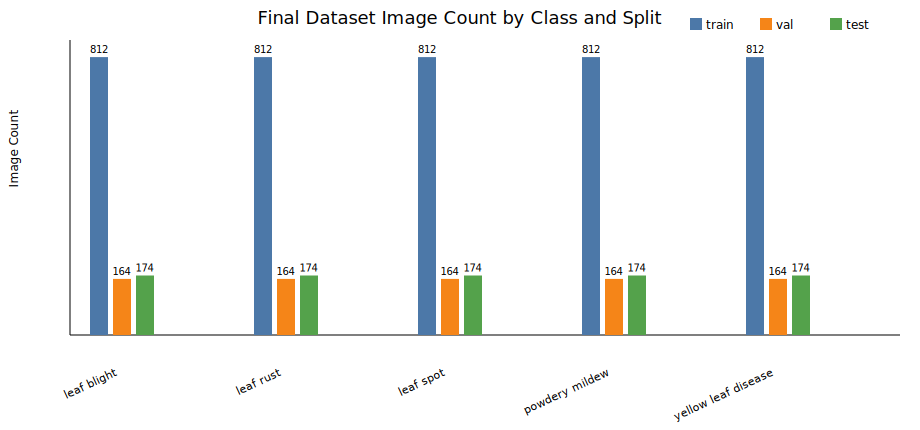

In [7]:
plot_df = summary_df.copy()
plt.figure(figsize=(10, 5))
for split in ['train', 'val', 'test']:
    split_df = plot_df[plot_df['split'] == split]
    plt.bar(split_df['class'], split_df['image_count'], label=split)

plt.title('Final Dataset Image Count by Class and Split')
plt.xlabel('Class')
plt.ylabel('Image Count')
plt.xticks(rotation=25, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Technical File Check

This cell checks file readability and image size only. It does not prove that every image label is correct, because image relevance was checked manually.


In [8]:
def verify_final_dataset_from_notebook():
    rows = []
    issue_rows = []
    for split in ['train', 'val', 'test']:
        for class_name in CLASSES:
            class_dir = FINAL_DIR / split / class_name
            image_files = sorted(class_dir.glob('*.jpg'))
            readable_files = 0
            unreadable_files = 0
            size_mismatch_files = 0
            for image_path in image_files:
                try:
                    with Image.open(image_path) as img:
                        if img.size != IMAGE_SIZE:
                            size_mismatch_files += 1
                            issue_rows.append({'path': str(image_path), 'issue': f'size_mismatch_{img.size}'})
                        readable_files += 1
                except Exception as exc:
                    unreadable_files += 1
                    issue_rows.append({'path': str(image_path), 'issue': repr(exc)})
            rows.append({
                'split': split,
                'class': class_name,
                'image_count': len(image_files),
                'readable_files': readable_files,
                'unreadable_files': unreadable_files,
                'size_mismatch_files': size_mismatch_files,
            })

    verification_df = pd.DataFrame(rows)
    issues_df = pd.DataFrame(issue_rows, columns=['path', 'issue'])
    return verification_df, issues_df

verification_df, issues_df = verify_final_dataset_from_notebook()
print('Issue count:', len(issues_df))
verification_df


Issue count: 0
Duplicate count: 0


split,class,image_count,readable_files,unreadable_files,size_mismatch_files
train,leaf_blight,812,812,0,0
train,leaf_rust,812,812,0,0
train,leaf_spot,812,812,0,0
train,powdery_mildew,812,812,0,0
train,yellow_leaf_disease,812,812,0,0
val,leaf_blight,164,164,0,0
val,leaf_rust,164,164,0,0
val,leaf_spot,164,164,0,0
val,powdery_mildew,164,164,0,0
val,yellow_leaf_disease,164,164,0,0


## 12. Final Accepted Counts After Manual Cleaning

These are the final accepted counts from the cleaned `data/final` dataset used for the project. The final image dataset is stored in Google Drive, while GitHub stores this notebook, report files, and the dataset link.


In [9]:
FINAL_ACCEPTED_COUNTS = pd.DataFrame([
    {'class': 'yellow_leaf_disease', 'raw_count': 1600, 'processed_count': 1150, 'train': 812, 'validation': 164, 'test': 174, 'total': 1150},
    {'class': 'leaf_rust', 'raw_count': 1534, 'processed_count': 1150, 'train': 812, 'validation': 164, 'test': 174, 'total': 1150},
    {'class': 'powdery_mildew', 'raw_count': 1600, 'processed_count': 1150, 'train': 812, 'validation': 164, 'test': 174, 'total': 1150},
    {'class': 'leaf_spot', 'raw_count': 1599, 'processed_count': 1150, 'train': 812, 'validation': 164, 'test': 174, 'total': 1150},
    {'class': 'leaf_blight', 'raw_count': 1200, 'processed_count': 1150, 'train': 812, 'validation': 164, 'test': 174, 'total': 1150},
])

total_row = pd.DataFrame([{
    'class': 'TOTAL',
    'raw_count': FINAL_ACCEPTED_COUNTS['raw_count'].sum(),
    'processed_count': FINAL_ACCEPTED_COUNTS['processed_count'].sum(),
    'train': FINAL_ACCEPTED_COUNTS['train'].sum(),
    'validation': FINAL_ACCEPTED_COUNTS['validation'].sum(),
    'test': FINAL_ACCEPTED_COUNTS['test'].sum(),
    'total': FINAL_ACCEPTED_COUNTS['total'].sum(),
}])

final_accepted_summary = pd.concat([FINAL_ACCEPTED_COUNTS, total_row], ignore_index=True)
final_accepted_summary.to_csv(REPORTS_DIR / 'data_engineering_final_report.csv', index=False)
final_accepted_summary


class,raw_count,processed_count,train,validation,test,total
yellow_leaf_disease,1600,1150,812,164,174,1150
leaf_rust,1534,1150,812,164,174,1150
powdery_mildew,1600,1150,812,164,174,1150
leaf_spot,1599,1150,812,164,174,1150
leaf_blight,1200,1150,812,164,174,1150
TOTAL,7533,5750,4060,820,870,5750
